In [108]:
import pygmt
import xarray as xr
import numpy as np

In [109]:
dset_mars = xr.open_dataset('mola32.nc')
dset_mars

<xarray.Dataset> Size: 133MB
Dimensions:    (latitude: 5760, longitude: 11520)
Coordinates:
  * latitude   (latitude) float32 23kB 89.98 89.95 89.92 ... -89.95 -89.98
  * longitude  (longitude) float32 46kB 0.01562 0.04688 0.07812 ... 360.0 360.0
Data variables:
    alt        (latitude, longitude) int16 133MB ...
Attributes:
    title:    MOLA Topography - 32 pixels/degree
    history:  Built from original MOLA file megt90n000fb.img

In [110]:
dset_mars_topo = dset_mars.alt.astype(float)
dset_mars_topo = pygmt.grdsample(grid=dset_mars_topo, toggle=True, spacing=[1,1])

grdsample [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdsample [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdsample (gmtapi_init_grdheader): Please select compatible -R and -I values
grdsample [WARNING]: Output sampling interval in x exceeds input interval and may lead to aliasing.
grdsample [WARNING]: Output sampling interval in y exceeds input interval and may lead to aliasing.


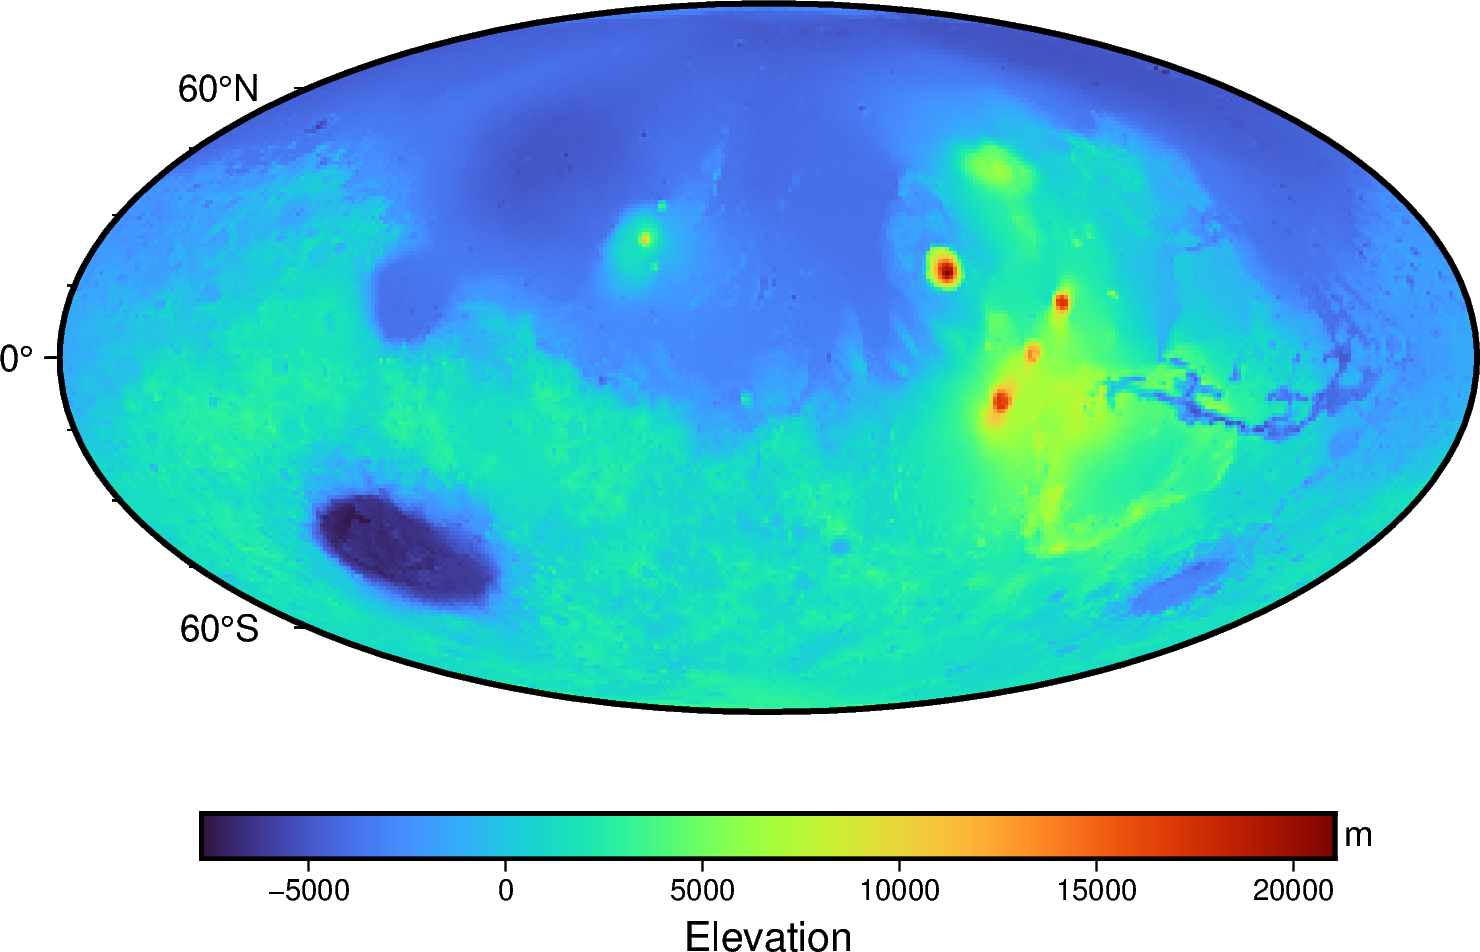

In [111]:
fig = pygmt.Figure()

fig.grdimage(grid=dset_mars_topo,region='g',frame=True,projection='W12c')
fig.colorbar(frame=['a5000','x+lElevation','y+lm'])

fig.show()

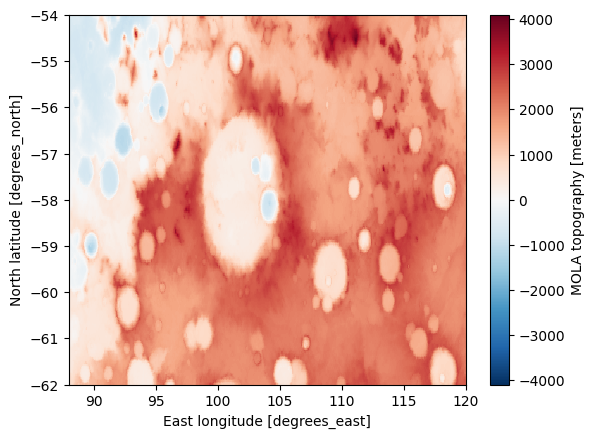

In [112]:
dset_scarps = dset_mars.sel(latitude=slice(-54,-62),longitude=slice(88,120)).alt.astype(float)
dset_scarps.plot()

In [119]:
longitudes=[114,109.4,93.7,108.9,89.8,96.3,91.9,103.1,92.1]
latitudes=[-56.6,-55.1,-58.3,-55.1,-57.2,-56.9,-57.2,-56.2,-60.8]
scarps=['South 1','South 2','South 3','South 4','South 5','South 6','South 7','South 13','South 19']
dips=[5.09,7.99,12.63,6.39,5.58,9.44,3.83,7.13,12.56]
diplabel=['5.09°','7.99°','12.63°','6.39°','5.58°','9.44°','3.83°','7.13°','12.56°']
strike=[214.16+90,213.49+90,228.48+90,178.97+90,230.29+90,257.39+90,257.71+90,187.32+90,242.74+90]
dipdir=[214.16,213.49,228.48,178.97,230.29,257.39,257.71,187.32,242.74]

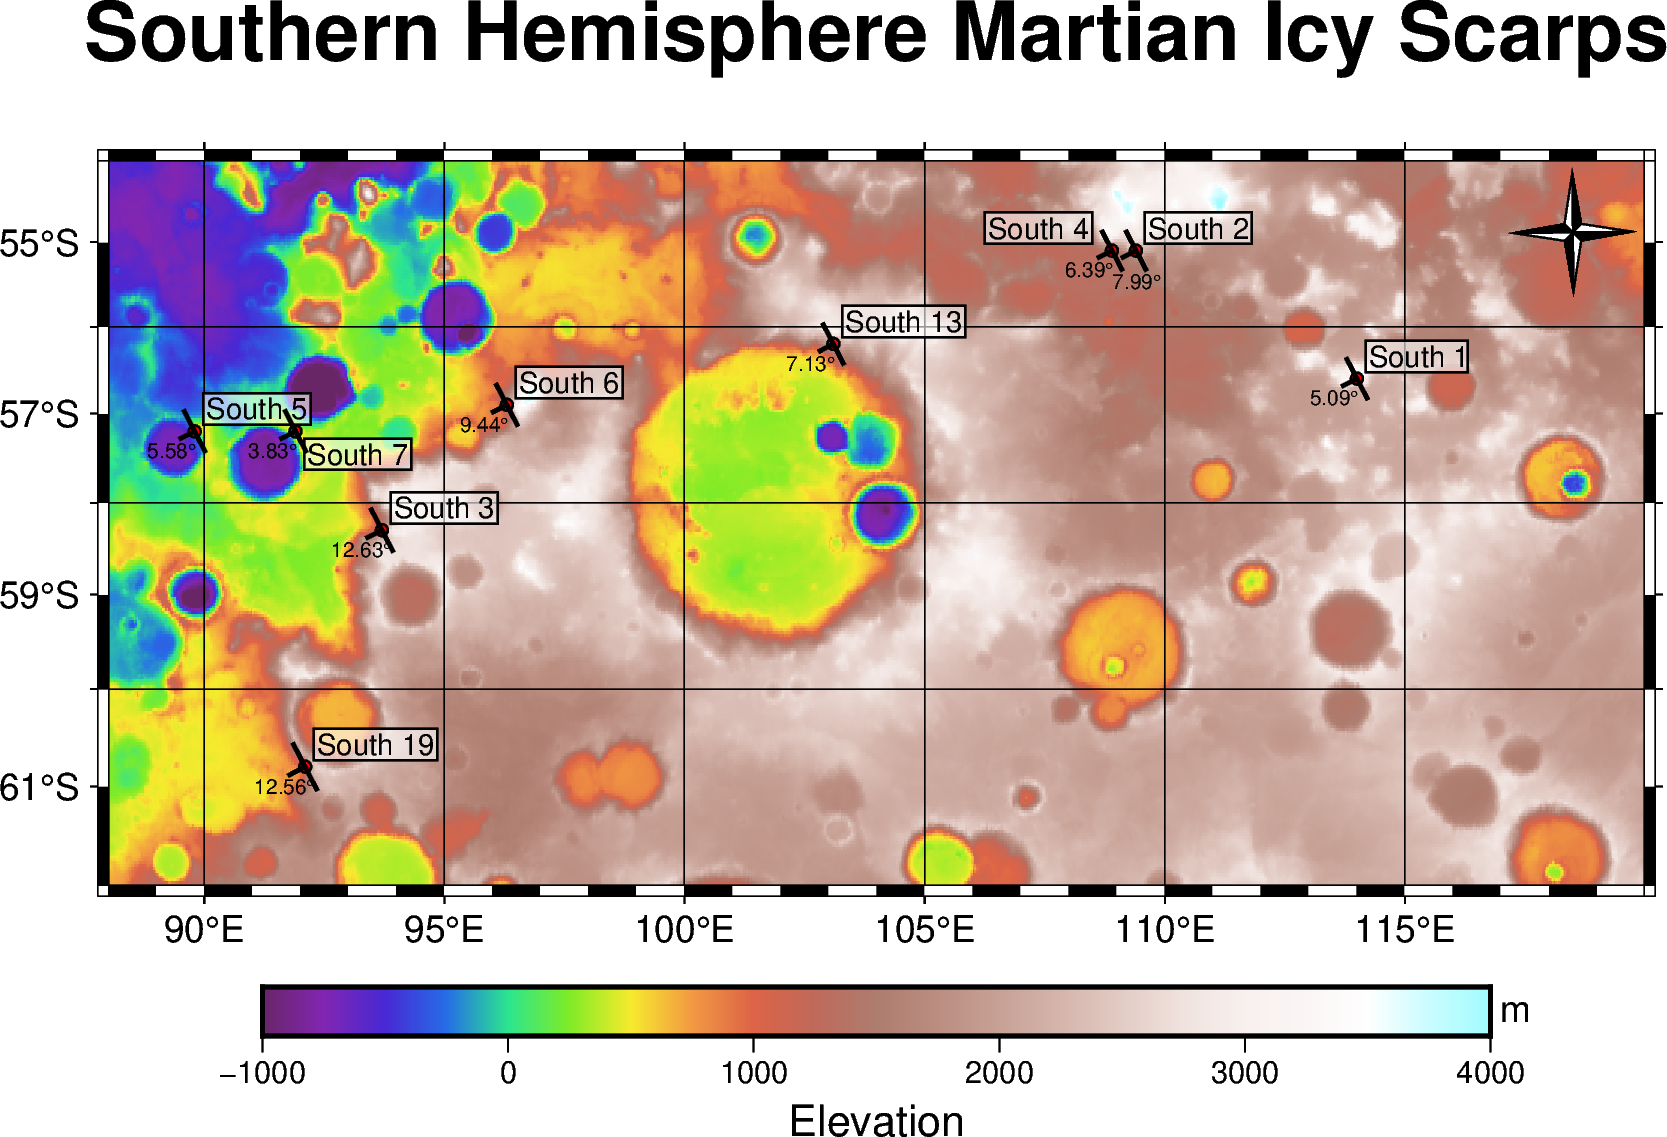

In [161]:
fig = pygmt.Figure()
# note I can add projection, after cmap and after, frame (and control frame)
pygmt.makecpt(
    cmap="@mars_relief.cpt",
    series=[-1000, 4000, 250],
    continuous=True
)
fig.grdimage(grid=dset_scarps,projection='M13c',frame=["xa5f1g5", "ya1f1g2",'+t Southern Hemisphere Martian Icy Scarps'],cmap=True)
# also, I can add a colorbar (later)
fig.colorbar(frame=["a1000", "x+lElevation", "y+lm"])
fig.plot(x=longitudes,y=latitudes, style="c0.1c",
    fill="red",pen="0.5p,black")
offsets = [
    (0.1, 0.10),   # South 1 
    (0.1, 0.10),   # South 2 
    (0.1, 0.10),   # South 3
    (-1.05, 0.10),  # South 4
    (0.1, 0.10),   # South 5
    (0.1, 0.10),  # South 6
    (0.1, -0.10),   # South 7
    (0.1, 0.10),  # South 13
    (0.1, 0.10)    # South 19
]
offsets_dip = [
    (-0.4, -0.10),   # South 1 
    (-0.2, -0.20),   # South 2 
    (-0.43, -0.10),   # South 3
    (-0.4, -0.10),  # South 4
    (-0.4, -0.10),   # South 5
    (-0.4, -0.10),  # South 6
    (-0.4, -0.10),   # South 7
    (-0.4, -0.10),  # South 13
    (-0.43, -0.10)    # South 19
]

def strike_dip(fig, lon, lat, strike, dipdir, Ls=0.55, Ld=0.2):
    sr = np.radians(strike)
    dr = np.radians(dipdir)
    c = np.cos(np.radians(lat))

    # Strike line
    dx = Ls / 2 * np.sin(sr) / c
    dy = Ls / 2 * np.cos(sr)

    fig.plot(
        x=[lon-dx, lon+dx],
        y=[lat-dy, lat+dy],
        pen="1p,black"
    )

    # Dip tick
    dx = Ld * np.sin(dr) / c
    dy = Ld * np.cos(dr)

    fig.plot(
        x=[lon, lon+dx],
        y=[lat, lat+dy],
        pen="1p,black"
    )



for lon, lat, name, (dx, dy) in zip(
    longitudes, latitudes, scarps, offsets
):
    fig.text(
        x=lon,
        y=lat,
        text=name,
        font="7p,Helvetica,black",
        justify="LB" if dy > 0 else "LT",
        offset=f"{dx}c/{dy}c",
        fill='white@40',
        pen="0.5p,black",
    )
    strike_dip(fig, lon, lat, s, dd)
fig.basemap(rose="jTR+w1c+f")

for lon, lat, name, (dx, dy) in zip(
    longitudes, latitudes, diplabel, offsets_dip
):
    fig.text(
        x=lon,
        y=lat,
        text=name,
        font="5p,Helvetica,black",
        justify="LB" if dy > 0 else "LT",
        offset=f"{dx}c/{dy}c",
        #fill='white@40',
        #pen="0.5p,black",
    )
    #strike_dip(fig, lon, lat, s, dd)
    
fig.savefig('ScarpSiteMap.png')
fig.show()